In [1]:
import pandas as pd
import numpy as np

feature_path = r"C:\Users\hp\AI-Enterprise-Workflow-Incident-Intelligence-Platform\AI-Enterprise-Workflow-Incident-Intelligence-Platform\dataset\features\tickets_features.csv"

df = pd.read_csv(feature_path)

df.head()

,ticket_text_clean,type,priority,queue,language,subject_length,body_length
0,unvorhergesehener absturz der datenanalyse pla...,Incident,low,General Inquiry,de,52,252
1,customer support inquiry seeking information o...,Request,medium,Customer Service,en,24,225
2,data analytics for investment i am contacting ...,Request,medium,Customer Service,en,29,696
3,krankenhaus dienstleistung problem ein medien ...,Incident,high,Customer Service,de,34,221
4,security dear customer support i am reaching o...,Request,medium,Customer Service,en,8,675


In [2]:
print(df.shape)
print(df['priority'].value_counts())

(20000, 7)
priority
medium    8144
high      7801
low       4055
Name: count, dtype: int64


In [3]:
X = df['ticket_text_clean']
y = df['priority']

In [4]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (20000,)
Target: (20000,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (16000,)
Testing : (4000,)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF:", X_train_tfidf.shape)
print("Testing TF-IDF :", X_test_tfidf.shape)

Training TF-IDF: (16000, 10000)
Testing TF-IDF : (4000, 10000)


In [7]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.50725

Classification Report:
              precision    recall  f1-score   support

        high       0.53      0.58      0.55      1560
         low       0.48      0.15      0.22       811
      medium       0.49      0.62      0.55      1629

    accuracy                           0.51      4000
   macro avg       0.50      0.45      0.44      4000
weighted avg       0.50      0.51      0.48      4000



In [9]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [10]:
print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.50575

SVM Classification Report:
              precision    recall  f1-score   support

        high       0.53      0.57      0.55      1560
         low       0.42      0.29      0.34       811
      medium       0.51      0.55      0.53      1629

    accuracy                           0.51      4000
   macro avg       0.49      0.47      0.47      4000
weighted avg       0.50      0.51      0.50      4000



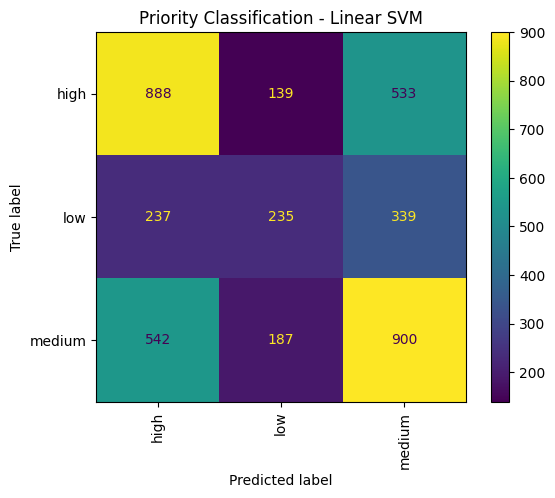

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    xticks_rotation='vertical'
)

plt.title("Priority Classification - Linear SVM")
plt.show()

In [12]:
svm_balanced = LinearSVC(
    class_weight='balanced',
    random_state=42
)

svm_balanced.fit(X_train_tfidf, y_train)

y_pred_balanced = svm_balanced.predict(X_test_tfidf)

print("Balanced SVM Accuracy:",
      accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced SVM Accuracy: 0.49975

Classification Report:
              precision    recall  f1-score   support

        high       0.54      0.54      0.54      1560
         low       0.38      0.40      0.39       811
      medium       0.52      0.51      0.51      1629

    accuracy                           0.50      4000
   macro avg       0.48      0.48      0.48      4000
weighted avg       0.50      0.50      0.50      4000



In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to des

In [14]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'C': 2, 'class_weight': 'balanced'}

Best CV Macro F1:
0.4795701330459168


In [15]:
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_tfidf)

print(
    "Tuned SVM Accuracy:",
    accuracy_score(y_test, y_pred_tuned)
)

print("\nTuned SVM Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned SVM Accuracy: 0.49275

Tuned SVM Classification Report:
              precision    recall  f1-score   support

        high       0.54      0.54      0.54      1560
         low       0.37      0.39      0.38       811
      medium       0.51      0.50      0.51      1629

    accuracy                           0.49      4000
   macro avg       0.47      0.48      0.47      4000
weighted avg       0.49      0.49      0.49      4000



In [16]:
priority_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Balanced Linear SVM",
        "Tuned Linear SVM"
    ],
    "Accuracy": [
        0.50725,
        0.50575,
        0.49975,
        0.49275
    ],
    "Macro F1": [
        0.44,
        0.47,
        0.48,
        0.47
    ],
    "Low F1": [
        0.22,
        0.34,
        0.39,
        0.38
    ]
})

priority_results

,Model,Accuracy,Macro F1,Low F1
0,Logistic Regression,0.50725,0.44,0.22
1,Linear SVM,0.50575,0.47,0.34
2,Balanced Linear SVM,0.49975,0.48,0.39
3,Tuned Linear SVM,0.49275,0.47,0.38


In [17]:
print("Best Priority Model: Balanced Linear SVM")
print("Macro F1: 0.48")
print("Low-class F1: 0.39")

Best Priority Model: Balanced Linear SVM
Macro F1: 0.48
Low-class F1: 0.39
